# Step1:import libraries

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from skimage import data
from skimage.filters import threshold_otsu
from skimage.filters import threshold_multiotsu
from skimage.transform import resize
from skimage.util import img_as_ubyte
from scipy import ndimage

In [17]:
# Set plotting style and parameters
sns.set_style('whitegrid')
plt.rcParams.update({   # Runtime Configuration Parameters
    'figure.figsize': (12, 8),
    'figure.dpi': 100,  # Sharper images for display
    'font.size': 10     # Consistent font size
})

# Step2:load and resize image

In [18]:
# Load sample image and check basic properties
# 下面注释掉的代码用于加载自己的图像
# image = Image.open("7.jpg")
# image = image.convert("L") # 转化为灰度图
# original_img = np.array(image)  # 转换为NumPy数组
original_img = data.camera() # Sample grayscale image from skimage
h_original, w_original = original_img.shape
dtype_original = original_img.dtype
intensity_range_original = (original_img.min(), original_img.max())

# Print COMPLETE original image info (not just shape)
print(f"\n📊 Original Image Properties:")
print(f"   - Dimensions: {h_original}px (height) × {w_original}px (width)")
print(f"   - Data type: {dtype_original}")
print(f"   - Intensity range (black → white): {intensity_range_original[0]} → {intensity_range_original[1]}")
print(f"   - Total pixels: {h_original * w_original:,}")  # Add commas for readability

# Resize logic (preserve aspect ratio, cap at 256px max dimension)
max_size = 256
scale = min(max_size / h_original, max_size / w_original)  # Scale to fit max_size
h_resized, w_resized = int(h_original * scale), int(w_original * scale)

# Resize and convert to 8-bit (ubyte) for consistency
resized_img = resize(
    original_img, 
    (h_resized, w_resized), 
    anti_aliasing=True,  # Reduce jagged edges
    preserve_range=True  # Keep intensity values (0-255)
)
resized_img = resized_img / 255.0  # Normalize to 0-1 range first
resized_img = img_as_ubyte(resized_img)  # Convert to 8-bit (0-255)

# Calculate intensity range **after** conversion (now it's defined)
intensity_range_resized = (resized_img.min(), resized_img.max())

# Print resized image info (now intensity_range_resized exists)
print(f"\n📏 Resized Image Properties (aspect ratio preserved):")
print(f"   - Dimensions: {h_resized}px (height) × {w_resized}px (width)")
print(f"   - Scaling factor applied: {scale:.2f}x")
print(f"   - Intensity range (after resizing): {intensity_range_resized[0]} → {intensity_range_resized[1]}")
print(f"   - Total pixels: {h_resized * w_resized:,}")



📊 Original Image Properties:
   - Dimensions: 512px (height) × 512px (width)
   - Data type: uint8
   - Intensity range (black → white): 0 → 255
   - Total pixels: 262,144

📏 Resized Image Properties (aspect ratio preserved):
   - Dimensions: 256px (height) × 256px (width)
   - Scaling factor applied: 0.50x
   - Intensity range (after resizing): 2 → 255
   - Total pixels: 65,536


# Step3:display original vs resized

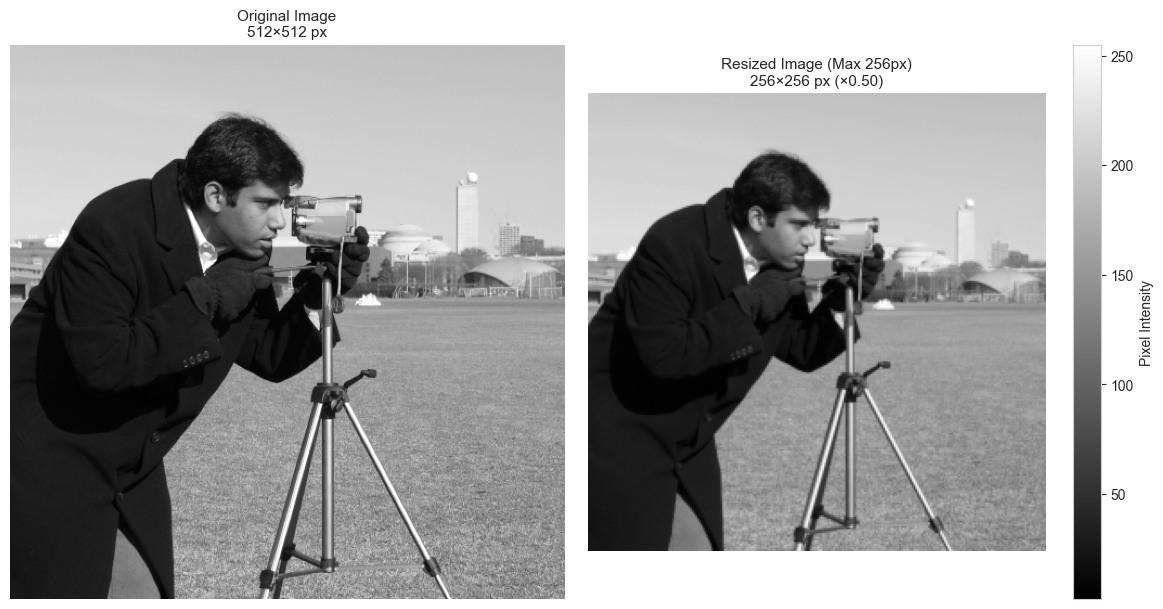

In [19]:
# Add pixel dimensions to titles for clarity
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image (with dimensions in title)
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f'Original Image\n{h_original}×{w_original} px', fontsize=11)
axes[0].axis('off')

# Resized image (with scaling factor in title)
axes[1].imshow(resized_img, cmap='gray')
axes[1].set_title(f'Resized Image (Max 256px)\n{h_resized}×{w_resized} px (×{scale:.2f})', fontsize=11)
axes[1].axis('off')
# 添加颜色条，并标注 "Pixel Intensity"
cbar = fig.colorbar(axes[1].imshow(resized_img, cmap='gray'), ax=axes[1])
cbar.set_label("Pixel Intensity")

plt.tight_layout()

plt.show()

# Step4:Global Otsu

In [20]:
thresh = threshold_otsu(resized_img) # One threshold for the whole image
print(f"Optimal threshold calculated by Otsu's method: {thresh}")

binary = resized_img > thresh

Optimal threshold calculated by Otsu's method: 102


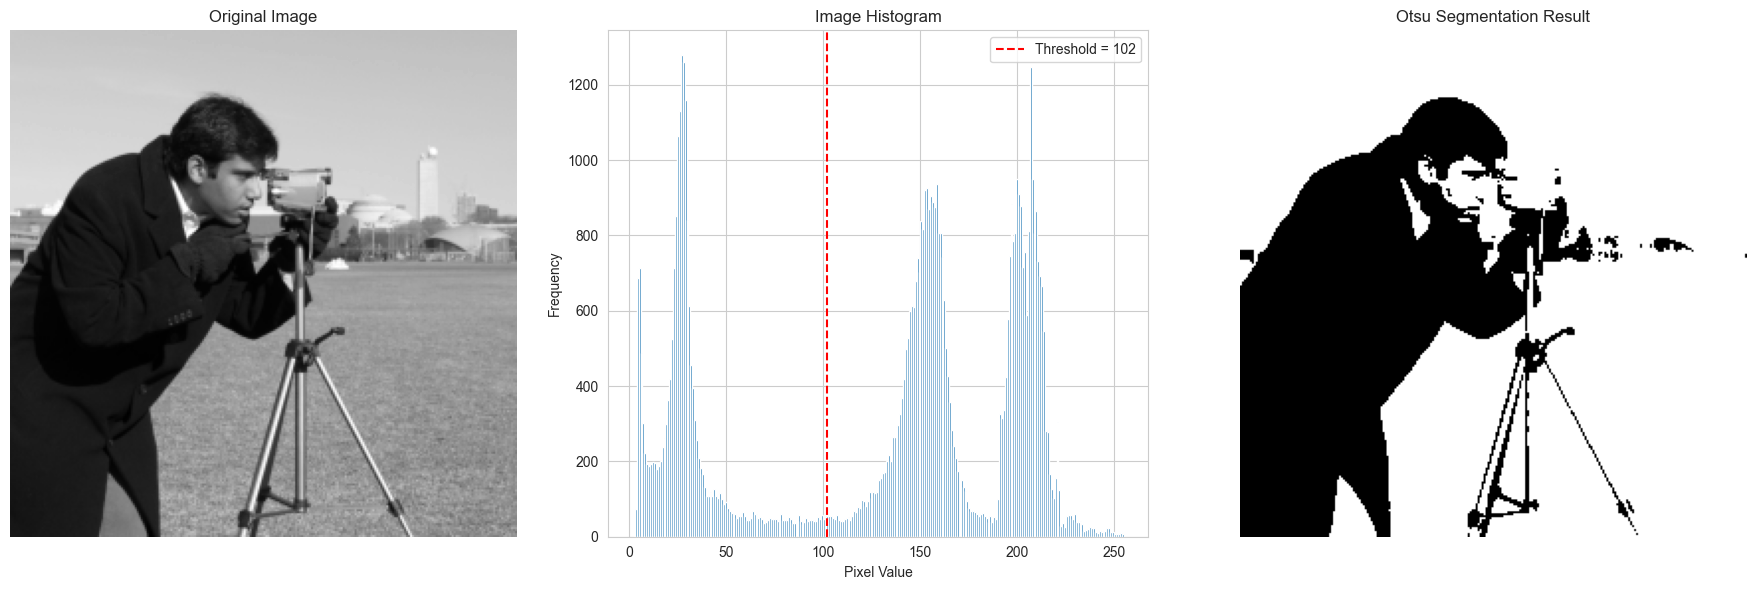

In [21]:
# Visualize resized image, histogram, and segmentation result
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(resized_img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].hist(resized_img.ravel(), bins=256)
ax[1].set_title('Image Histogram')
ax[1].axvline(thresh, color='r', linestyle='--', label=f'Threshold = {thresh}')
ax[1].legend()
ax[1].set_xlabel('Pixel Value')
ax[1].set_ylabel('Frequency')

ax[2].imshow(binary, cmap='gray')
ax[2].set_title('Otsu Segmentation Result')
ax[2].axis('off')

plt.tight_layout()
plt.show()


📈 Class-Level Statistics (for 2 Classes):
   - Class 0:
     • Pixel count: 20,857 (31.8% of total)
     • Mean intensity: 30.2 (darker = lower)
   - Class 1:
     • Pixel count: 44,679 (68.2% of total)
     • Mean intensity: 175.2 (darker = lower)


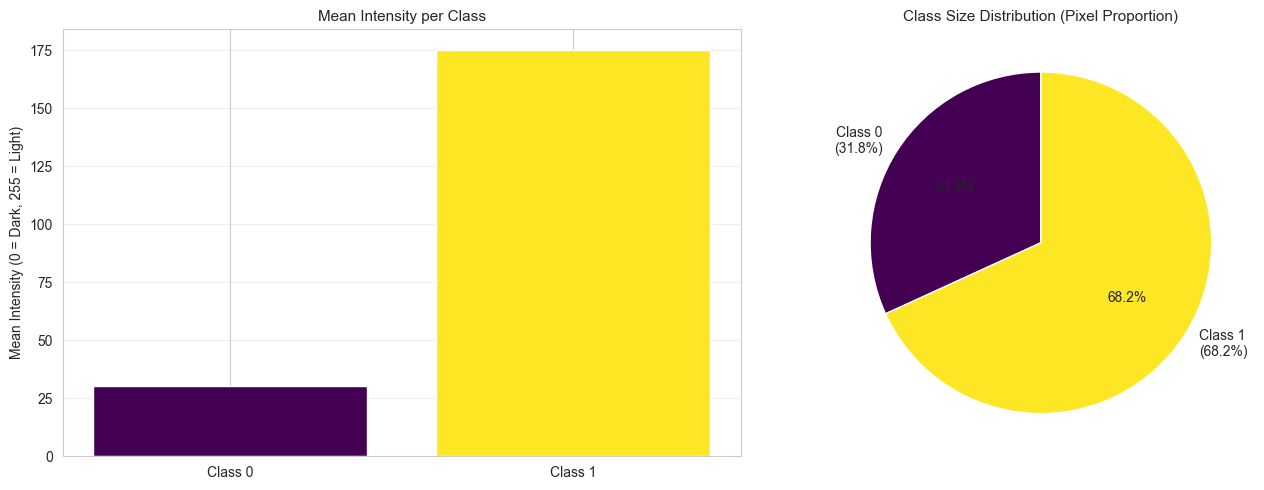

In [22]:
# Display stats
# Use 2-class segmentation for stats (balanced for demo)
num_classes_stats = 2
thresholds_stats = threshold_multiotsu(resized_img, classes=num_classes_stats)
regions_stats = np.digitize(resized_img, bins=thresholds_stats)

# Compute stats (size, mean intensity) per class
class_sizes = []
class_mean_intensities = []
for class_num in range(num_classes_stats):
    # Count pixels in the class
    size = np.sum(regions_stats == class_num)
    class_sizes.append(size)
    # Mean intensity of the class
    mean_int = np.mean(resized_img[regions_stats == class_num])
    class_mean_intensities.append(mean_int)

# Print detailed class stats
print(f"\n📈 Class-Level Statistics (for {num_classes_stats} Classes):")

for class_num in range(num_classes_stats):
    # Calculate percentage of total pixels
    size_pct = (class_sizes[class_num] / regions_stats.size) * 100
    print(f"   - Class {class_num}:")
    print(f"     • Pixel count: {class_sizes[class_num]:,} ({size_pct:.1f}% of total)")
    print(f"     • Mean intensity: {class_mean_intensities[class_num]:.1f} (darker = lower)")

# Plot stats (bar + pie chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Mean intensity per class
axes[0].bar(
    [f'Class {i}' for i in range(num_classes_stats)],
    class_mean_intensities,
    color=plt.cm.viridis(np.linspace(0, 1, num_classes_stats))
)
axes[0].set_title('Mean Intensity per Class', fontsize=11)
axes[0].set_ylabel('Mean Intensity (0 = Dark, 255 = Light)')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart: Class size distribution (shows proportion)
wedges, texts, autotexts = axes[1].pie(
    class_sizes,
    labels=[f'Class {i}\n({size_pct:.1f}%)' for i, size_pct in zip(range(num_classes_stats), (s/regions_stats.size*100 for s in class_sizes))],
    colors=plt.cm.viridis(np.linspace(0, 1, num_classes_stats)),
    autopct='%1.1f%%',  # Show percentage on pie slices
    startangle=90
)
axes[1].set_title('Class Size Distribution (Pixel Proportion)', fontsize=11)

plt.tight_layout()
plt.show()

# Step5:Adaptive Otsu

In [23]:

def adaptive_otsu(image, window_size):
    """
    自适应Otsu阈值分割函数
    
    参数:
    image: 输入图像(灰度图)
    window_size: 滑动窗口大小(奇数)
    
    返回:
    binary_result: 二值化结果
    threshold_map: 局部阈值映射图
    """
    # 确保窗口大小为奇数，从而保证窗口有唯一的中心像素
    if window_size % 2 == 0:
        window_size += 1
        print(f"调整窗口大小为奇数: {window_size}")
    
    # 获取图像尺寸
    h, w = image.shape
    
    # 创建阈值映射图
    threshold_map = np.zeros_like(image, dtype=np.float32) # threshold_map 用来存储每个像素位置对应的局部 Otsu 阈值
    
    # 计算填充大小
    pad = window_size // 2
    
    # 对图像进行边界填充
    padded_image = np.pad(image, pad, mode='reflect')
    
    # 遍历每个像素，生成阈值映射图
    for i in range(h):
        for j in range(w):
            window = padded_image[i:i+window_size, j:j+window_size] # 提取局部窗口
            thresh = threshold_otsu(window)
            threshold_map[i, j] = thresh
    
    # 应用阈值映射进行二值化
    binary_result = (image > threshold_map).astype(np.uint8) * 255
    
    return binary_result, threshold_map
    

In [24]:
binary_15, threshold_map_15 = adaptive_otsu(resized_img, 15)
binary_35, threshold_map_35 = adaptive_otsu(resized_img, 35)

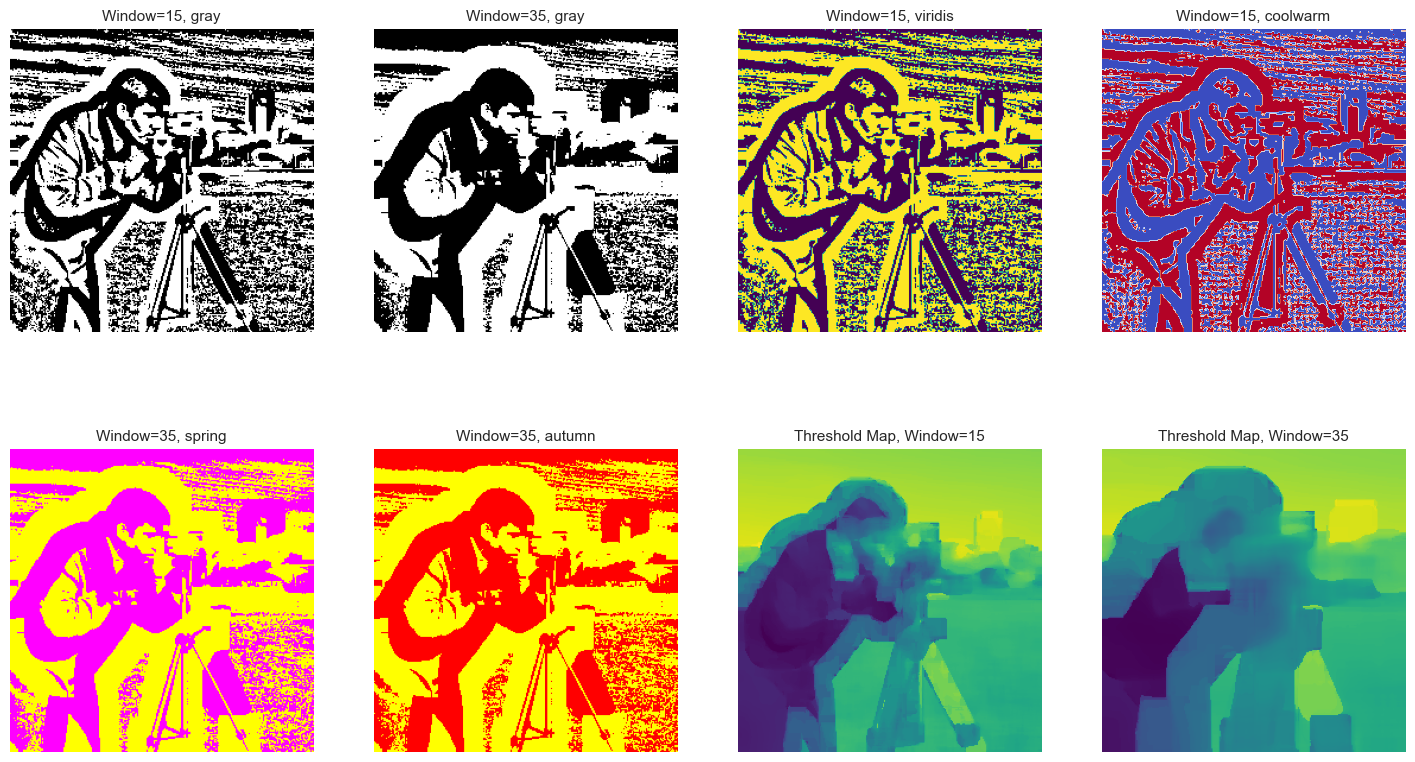

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

axes[0,0].imshow(binary_15, cmap='gray')
axes[0,0].set_title('Window=15, gray', fontsize=11)
axes[0,0].axis('off')

axes[0,1].imshow(binary_35, cmap='gray')
axes[0,1].set_title('Window=35, gray', fontsize=11)
axes[0,1].axis('off')

axes[0,2].imshow(binary_15, cmap='viridis')
axes[0,2].set_title('Window=15, viridis', fontsize=11)
axes[0,2].axis('off')

axes[0,3].imshow(binary_15, cmap='coolwarm')
axes[0,3].set_title('Window=15, coolwarm', fontsize=11)
axes[0,3].axis('off')

axes[1,0].imshow(binary_35, cmap='spring')
axes[1,0].set_title('Window=35, spring', fontsize=11)
axes[1,0].axis('off')

axes[1,1].imshow(binary_35, cmap='autumn')
axes[1,1].set_title('Window=35, autumn', fontsize=11)
axes[1,1].axis('off')

axes[1,2].imshow(threshold_map_15, cmap='viridis')
axes[1,2].set_title('Threshold Map, Window=15', fontsize=11)
axes[1,2].axis('off')

axes[1,3].imshow(threshold_map_35, cmap='viridis')
axes[1,3].set_title('Threshold Map, Window=35', fontsize=11)
axes[1,3].axis('off')



plt.show()